In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-lifted-polyps/07270b1b-84de-40d2-bbff-698bf3b91512.jpg
/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-lifted-polyps/40f6ef85-0e89-457c-aaae-cabe2bbe47ea.jpg
/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-lifted-polyps/3c38d8a9-52d4-415e-b8a2-25fa28d87393.jpg
/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-lifted-polyps/335adfe9-89ea-4ac7-bcba-1fdd4cc844da.jpg
/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-lifted-polyps/23745e74-a557-483f-aed6-beca9e90f303.jpg
/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-lifted-polyps/2335d64a-6f62-4f6e-a907-811850464a53.jpg
/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-lifted-polyps/607347c8-de2e-4e4f-a2fd-b09a7c898d24.jpg
/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-lifted-polyps/4b781702-e434-418e-8b62-7519aefa8b71.jpg


In [ ]:
! pip install thop 

In [3]:
from pathlib import Path
from dataclasses import dataclass
import random
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW

import torchvision
from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as T

import timm
import torchmetrics
from torchinfo import summary
from thop import profile
print("numpy : ",np.__version__)
print("sklearn : ",sklearn.__version__)
print("torch : ",torch.__version__)
print("torchmetrics : ",torchmetrics.__version__)
print("torchvision : ",torchvision.__version__)


numpy :  2.0.2
sklearn :  1.6.1
torch :  2.10.0+cu128
torchmetrics :  1.9.0
torchvision :  0.25.0+cu128


In [4]:
seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
@dataclass
class Config:
    data_dir: Path = Path("/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/")
    img_size: int = 512
    batch_size: int = 32
    num_workers: int = 4
    epochs: int = 20
    lr: float = 3e-4
    weight_decay: float = 1e-4
    num_classes: int = 8
    model_name: str = "mobilenetv3_small_100"
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

OUTPUT_DIR = Path("./outputs")
MODEL_DIR = OUTPUT_DIR / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(MODEL_DIR)

cfg = Config()

outputs/models


In [ ]:
class GIEndoscopyDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx] # ('~/kvasir-dataset/dyed-lifted-polyps/b4ad64a8098a.jpg',0)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [7]:
! ls /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset

dyed-lifted-polyps	esophagitis   normal-pylorus  polyps
dyed-resection-margins	normal-cecum  normal-z-line   ulcerative-colitis


In [8]:
from sklearn.model_selection import train_test_split
from pprint import pprint
# torchvision.datasets.ImageFolder assumes directory structure:
# root/
# ├── class_1/
# │   ├── img1.jpg
# │   ├── img2.jpg
# │
# ├── class_2/
# │   ├── img3.jpg
# │
# └── class_3/
full_ds = ImageFolder(cfg.data_dir)
print("Total images in all folders : ",len(full_ds))
pprint(full_ds.classes)
class_names = full_ds.classes
print("Class Mapping")
pprint(full_ds.class_to_idx)
samples = full_ds.samples
print("\nFirst 5 samples:")
pprint(full_ds.samples[:5])
labels = [y for _, y in samples]
train_samples, val_samples = train_test_split(
    samples, test_size=0.2, stratify=labels, random_state=42
)


Total images in all folders :  4000
['dyed-lifted-polyps',
 'dyed-resection-margins',
 'esophagitis',
 'normal-cecum',
 'normal-pylorus',
 'normal-z-line',
 'polyps',
 'ulcerative-colitis']
Class Mapping
{'dyed-lifted-polyps': 0,
 'dyed-resection-margins': 1,
 'esophagitis': 2,
 'normal-cecum': 3,
 'normal-pylorus': 4,
 'normal-z-line': 5,
 'polyps': 6,
 'ulcerative-colitis': 7}

First 5 samples:
[('/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-lifted-polyps/0053d7cd-549c-48cd-b370-b4ad64a8098a.jpg',
  0),
 ('/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-lifted-polyps/007d5aa7-7289-4bad-aa4a-5c3a259e9b19.jpg',
  0),
 ('/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-lifted-polyps/00cf9508-6ad1-4db9-840a-519c1d515c30.jpg',
  0),
 ('/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-lifted-polyps/01507fbd-4d38-4525-9768-7754710f507c.jpg',
  0),
 ('/kaggle/input/datasets/meetnagadia/kvasir-dataset/kva

In [9]:
train_tfms = T.Compose(
    [
        T.Resize((cfg.img_size, cfg.img_size)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=10),
        T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
        T.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05)),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)
val_tfms = T.Compose(
    [
        T.Resize((cfg.img_size, cfg.img_size)),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

In [10]:
train_ds = GIEndoscopyDataset(train_samples, train_tfms)
val_ds = GIEndoscopyDataset(val_samples, val_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
)

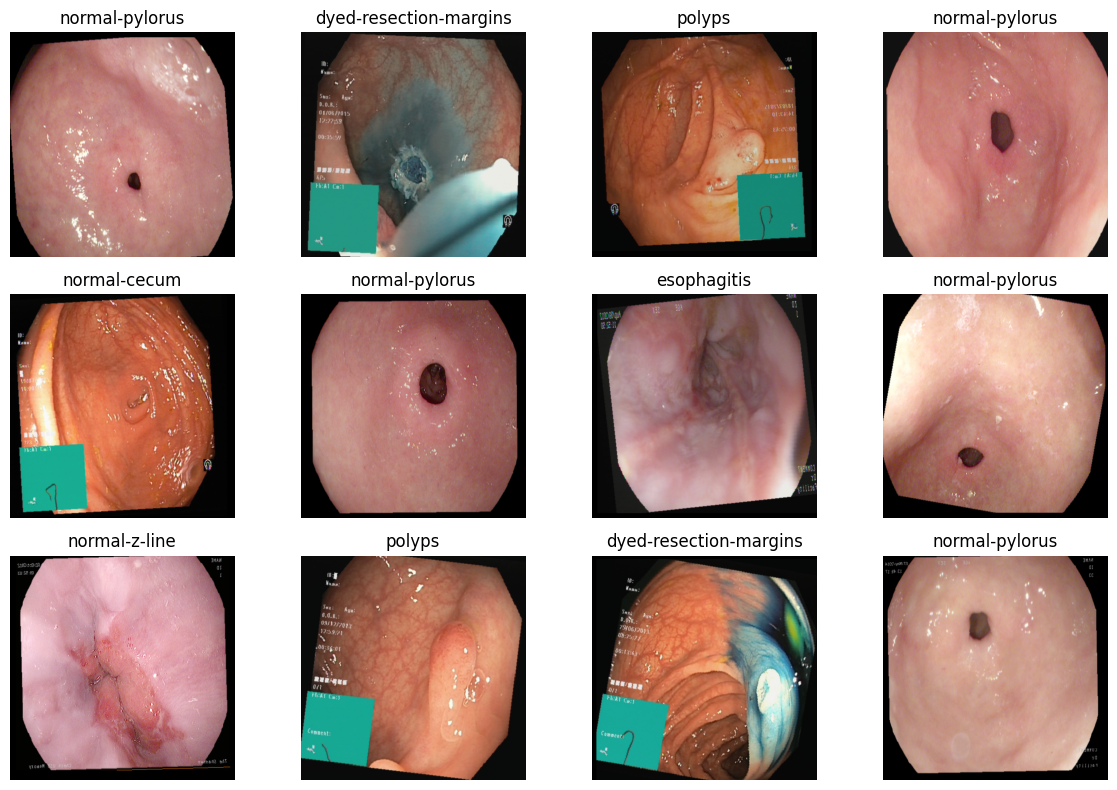

In [11]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
for ax, img, label in zip(axes.flatten(), images[:12], labels[:12]):
    img = img.permute(1, 2, 0).numpy()
    # undo normalization
    img = img * std + mean
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[label.item()])
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "train_img_samaples.png", dpi=150, bbox_inches='tight')
# plt.show()

In [12]:
model = timm.create_model(
    cfg.model_name, pretrained=True, num_classes=cfg.num_classes
).to(cfg.device)

model.safetensors:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

In [13]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params
param_size_mb = total_params * 4 / (1024**2)  # float32
dummy = torch.randn(1, 3, cfg.img_size,cfg.img_size).to(cfg.device)
macs, params = profile(model, inputs=(dummy,), verbose=False)

print(f"MACs:   {macs / 1e9:.3f} G")
print(f"Params: {params / 1e6:.3f} M")
print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Frozen Parameters:    {frozen_params:,}")
print(f"Approx model size: {param_size_mb:.2f} MB")
summary(
    model,
    input_size=(1, 3, 224, 224),
    col_names=["input_size", "output_size", "num_params", "mult_adds"],
)

MACs:   0.286 G
Params: 1.506 M
Total Parameters:     1,526,056
Trainable Parameters: 1,526,056
Frozen Parameters:    0
Approx model size: 5.82 MB


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Mult-Adds
MobileNetV3                                   [1, 3, 224, 224]          [1, 8]                    --                        --
├─Conv2d: 1-1                                 [1, 3, 224, 224]          [1, 16, 112, 112]         432                       5,419,008
├─BatchNormAct2d: 1-2                         [1, 16, 112, 112]         [1, 16, 112, 112]         32                        --
│    └─Identity: 2-1                          [1, 16, 112, 112]         [1, 16, 112, 112]         --                        --
│    └─Hardswish: 2-2                         [1, 16, 112, 112]         [1, 16, 112, 112]         --                        --
├─Sequential: 1-3                             [1, 16, 112, 112]         [1, 576, 7, 7]            --                        --
│    └─Sequential: 2-3                        [1, 16, 112, 112]         [1, 16, 56, 56]          

In [14]:
targets = np.array(labels)
class_counts = np.bincount(targets)
weights = 1.0 / class_counts
weights = torch.tensor(weights, dtype=torch.float).to(cfg.device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
acc_metric = torchmetrics.Accuracy(task="multiclass", num_classes=8).to(cfg.device)
bal_acc_metric = torchmetrics.Accuracy(
    task="multiclass", num_classes=8, average="macro"
).to(cfg.device)
f1_metric = torchmetrics.F1Score(task="multiclass", num_classes=8, average="macro").to(
    cfg.device
)
precision_metric = torchmetrics.Precision(
    task="multiclass", num_classes=8, average="macro"
).to(cfg.device)
recall_metric = torchmetrics.Recall(
    task="multiclass", num_classes=8, average="macro"
).to(cfg.device)
mcc_metric = torchmetrics.MatthewsCorrCoef(task="multiclass", num_classes=8).to(
    cfg.device
)
auroc_metric = torchmetrics.AUROC(task="multiclass", num_classes=8).to(cfg.device)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2
)

In [15]:
best_f1 = 0
history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "lr": [],
}

In [ ]:
main_pbar = tqdm(range(cfg.epochs), desc="Total Progress", position=0)

for epoch in main_pbar:
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    # The inner progress bar (Training Batches)
    # leave=False removes the bar once the epoch phase is done
    train_pbar = tqdm(
        train_loader, desc=f"Epoch {epoch + 1} [Train]", position=1, leave=False
    )

    for images, targets in train_pbar:
        images, targets = (
            images.to(cfg.device, non_blocking=True),
            targets.to(cfg.device, non_blocking=True),
        )

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        train_pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = running_train_loss / len(train_loader)

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    acc_metric.reset()

    # The inner progress bar (Validation Batches)
    val_pbar = tqdm(
        val_loader, desc=f"Epoch {epoch + 1} [Val]", position=1, leave=False
    )

    with torch.no_grad():
        for images, targets in val_pbar:
            images, targets = images.to(cfg.device), targets.to(cfg.device)
            logits = model(images)
            loss = criterion(logits, targets)

            preds = torch.argmax(logits, dim=1)
            acc_metric.update(preds, targets)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_acc = acc_metric.compute().item()

    # --- UPDATES & LOGGING ---
    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()  # Updated after the full epoch

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(
        f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.2e}"
    )

    # Save Best Model based on Validation Accuracy (since other metrics were removed)
    if val_acc > best_f1:
        best_f1 = val_acc
        torch.save(model.state_dict(), str(MODEL_DIR / "best_model.pt"))
        print("Saved best model.")

In [ ]:
import json
from pathlib import Path

output_path = OUTPUT_DIR / "history.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=4, ensure_ascii=False)

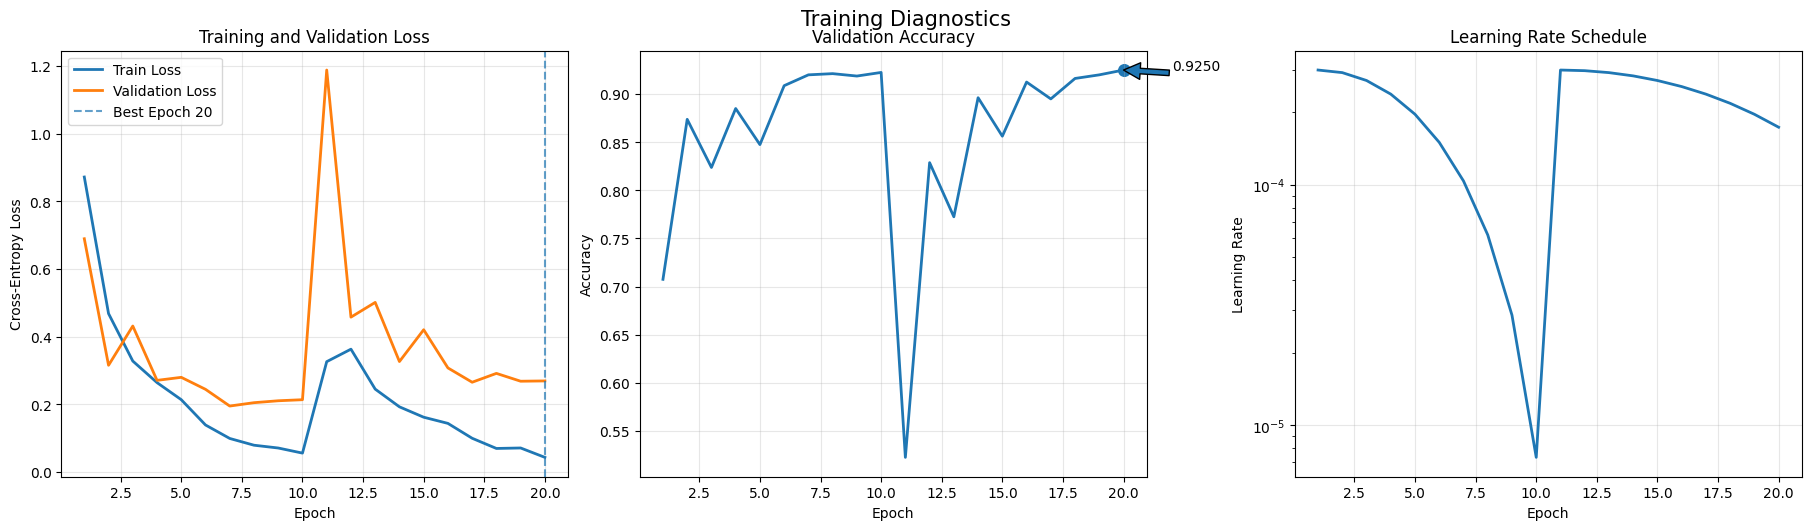

In [17]:
plt.style.use("seaborn-v0_8-darkgrid")

epochs = np.arange(1, len(history["train_loss"]) + 1)
best_epoch = np.argmax(history["val_acc"]) + 1
best_acc = np.max(history["val_acc"])

plt.style.use("default")  # or "ggplot"

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), constrained_layout=True)

# 1. Loss Curves
axes[0].plot(epochs, history["train_loss"], linewidth=2, label="Train Loss")
axes[0].plot(epochs, history["val_loss"], linewidth=2, label="Validation Loss")
axes[0].axvline(best_epoch, linestyle="--", alpha=0.7, label=f"Best Epoch {best_epoch}")
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

# 2. Validation Accuracy
axes[1].plot(epochs, history["val_acc"], linewidth=2)
axes[1].scatter(best_epoch, best_acc, s=70)
axes[1].annotate(
    f"{best_acc:.4f}",
    xy=(best_epoch, best_acc),
    xytext=(best_epoch + 2, best_acc),
    arrowprops=dict(),
)
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)

# 3. Learning Rate Schedule
axes[2].plot(epochs, history["lr"], linewidth=2)
axes[2].set_title("Learning Rate Schedule")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_yscale("log")  # important for LR plots
axes[2].grid(alpha=0.3)

fig.suptitle("Training Diagnostics", fontsize=15, y=1.03)
plt.savefig(OUTPUT_DIR / "training_stats.png", dpi=150, bbox_inches='tight')
# plt.show()

In [18]:
model.load_state_dict(
    torch.load(str(MODEL_DIR / "best_model.pt"), map_location=cfg.device)
)

model.eval()

all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    pbar = tqdm(val_loader, desc="Final Evaluation")

    for images, targets in pbar:
        images = images.to(cfg.device)
        targets = targets.to(cfg.device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.append(preds.cpu())
        all_targets.append(targets.cpu())
        all_probs.append(probs.cpu())

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()
all_probs = torch.cat(all_probs).numpy()

Final Evaluation:   0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
from sklearn.metrics import (
    balanced_accuracy_score,
    matthews_corrcoef,
    f1_score,
)

acc = (all_preds == all_targets).mean()
bal_acc = balanced_accuracy_score(all_targets, all_preds)
macro_f1 = f1_score(all_targets, all_preds, average="macro")
mcc = matthews_corrcoef(all_targets, all_preds)

print("FINAL TEST METRICS")
print(f"Accuracy:          {acc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"MCC:               {mcc:.4f}")

FINAL TEST METRICS
Accuracy:          0.9250
Balanced Accuracy: 0.9250
Macro F1:          0.9247
MCC:               0.9145


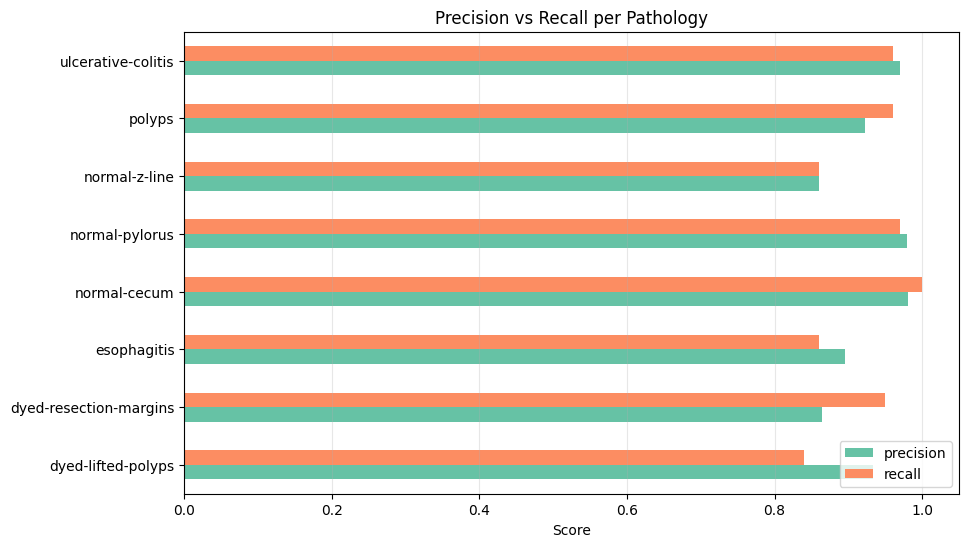

In [ ]:
report = classification_report(all_targets, all_preds, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose().iloc[:-3, :] # Exclude avg/accuracy rows

fig, ax = plt.subplots(figsize=(10, 6))
df_report[['precision', 'recall']].plot(kind='barh', ax=ax, color=['#66c2a5', '#fc8d62'])
ax.set_title("Precision vs Recall per Pathology")
ax.set_xlabel("Score")
plt.grid(axis='x', alpha=0.3)
plt.savefig(OUTPUT_DIR / "pvsr_per_class.png", dpi=150, bbox_inches='tight')
# plt.show()

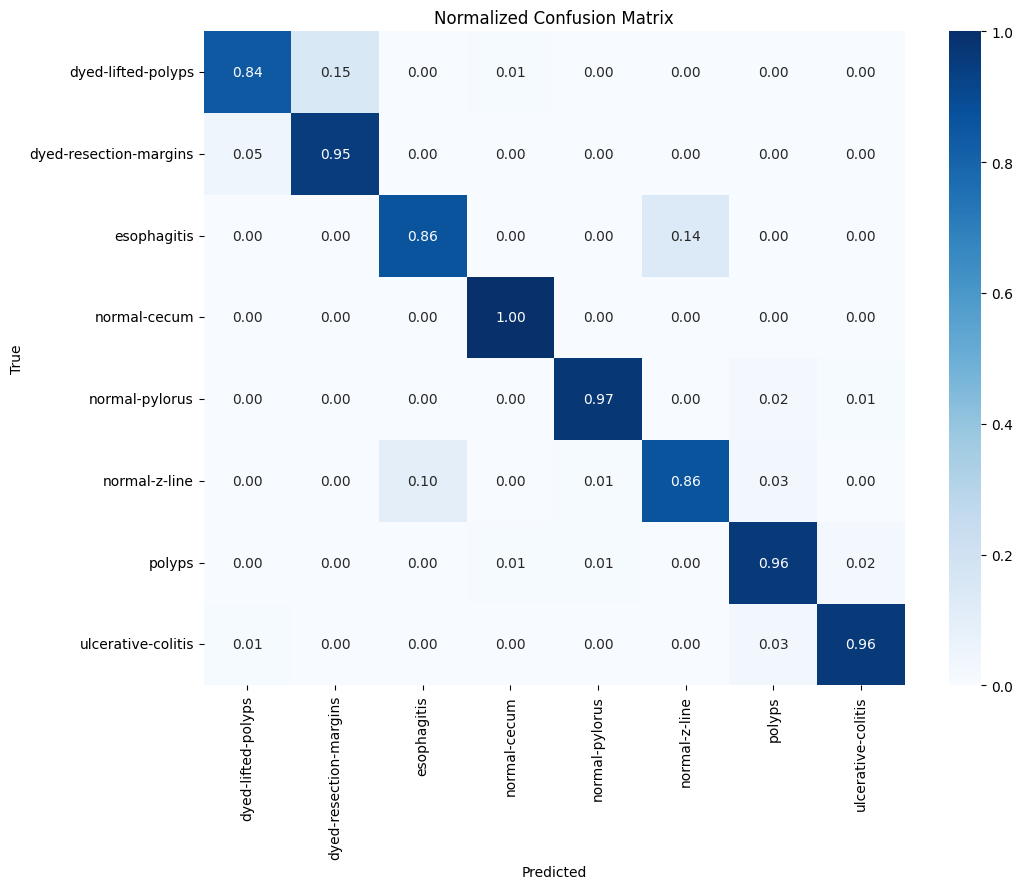

In [21]:
cm = confusion_matrix(all_targets, all_preds, normalize="true")
plt.figure(figsize=(11, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches='tight')
# plt.show()

In [22]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(all_targets, all_probs, multi_class="ovr")
print(f"Multiclass AUROC: {auc:.4f}")

Multiclass AUROC: 0.9954


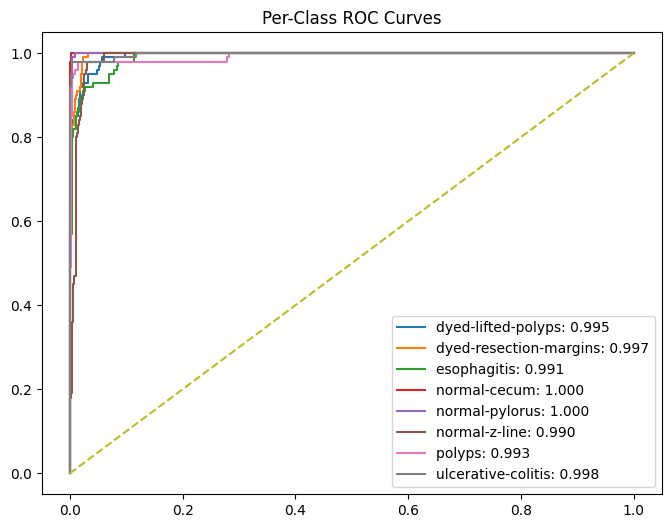

In [23]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(
    all_targets,
    classes=np.arange(len(class_names))
)

plt.figure(figsize=(8,6))

for i,name in enumerate(class_names):
    fpr,tpr,_ = roc_curve(
        y_true_bin[:,i],
        all_probs[:,i]
    )
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f"{name}: {roc_auc:.3f}")

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("Per-Class ROC Curves")
plt.savefig(OUTPUT_DIR / "roc_per_class.png", dpi=150, bbox_inches='tight')
# plt.show()

Misclassified: 60


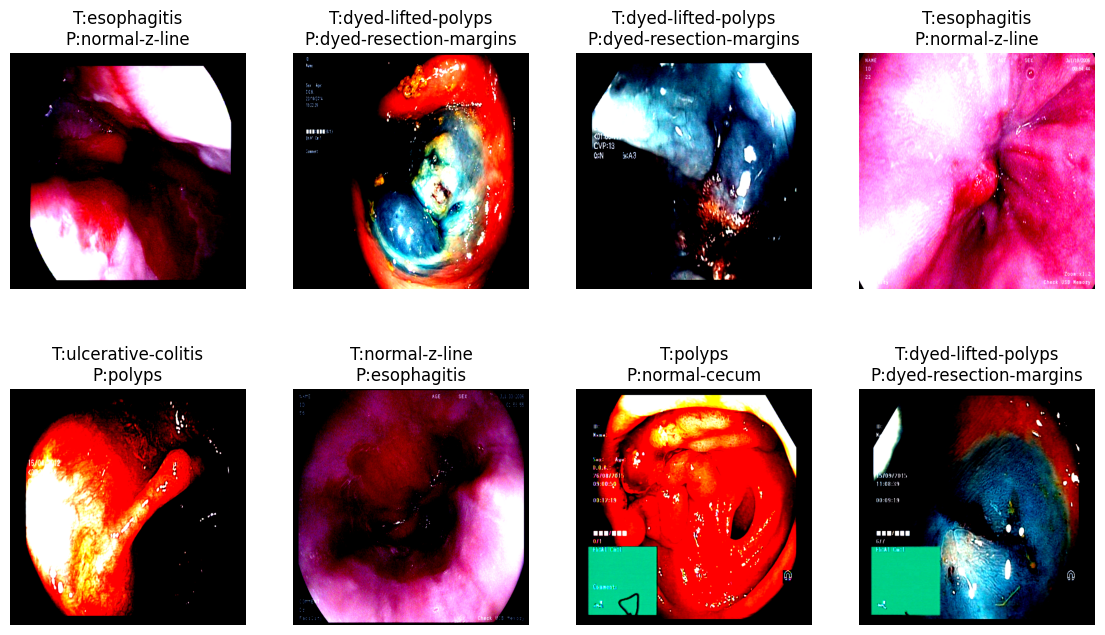

In [24]:
wrong = np.where(all_preds != all_targets)[0]
print(f"Misclassified: {len(wrong)}")
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
for ax, idx in zip(axes.flat, wrong[:8]):
    img, label = val_ds[idx]
    img = img.permute(1, 2, 0).numpy()
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(f"T:{class_names[all_targets[idx]]}\nP:{class_names[all_preds[idx]]}")
    ax.axis("off")
# plt.show()